## Permafrost Mask Creation

This code generates a permafrost mask following the procedure used in *Resample_Yearly_LULC.ipynb*.  
The resampled 25 km LULC dataset includes inland water bodies (class 210) and permanent snow/ice (class 220), both of which are excluded from the analysis.

Although LULC does not exhibit substantial year-to-year variation, annual LULC data were used to ensure accurate masking of these areas for each year.

As the LULC dataset is only available from 1992 to 2022, the permafrost mask for the period 1988–1991 was constructed using the 1992 LULC data.

In [2]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pdL
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable


if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")


## Create the land mask for regions north of 60°N

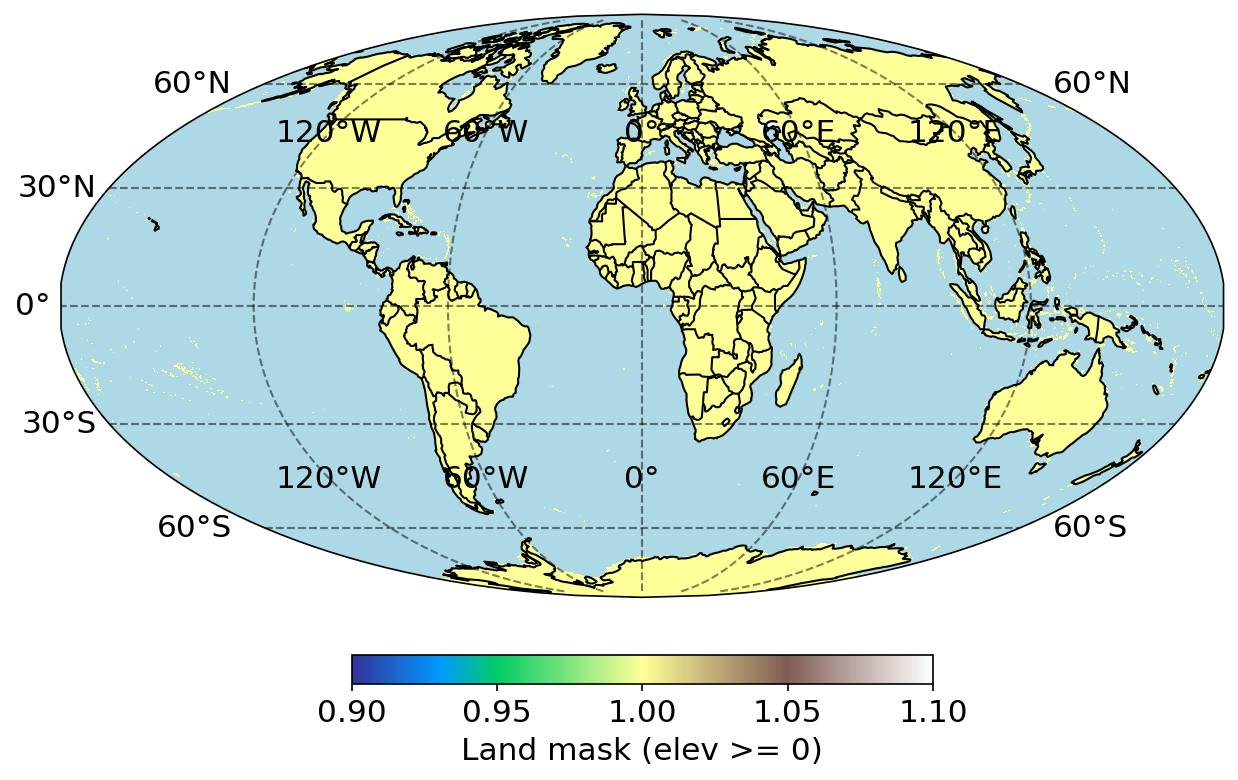

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

In [ ]:
start_year = 1992
end_year   = 2022

LULC_file = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/ESA_CCI_LULC_25km_60N_1992_2022.nc'
out_dir   = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'

with nc.Dataset(LULC_file) as ds:
    lat = ds.variables["lat"][:]
    lat = lat[:, 0]
    lon = ds.variables["lon"][:]
    lon = lon[0, :]
    lulc = ds.variables["lccs_class"]  # (lat, lon, number of years) = (120, 1440, 31)

    for yi, year in enumerate(range(start_year, end_year + 1)):
        L = lulc[:, :, yi].astype(np.int16)

        # Water(210) and permanent snow/ice(220) mask: NaN for the corresponding class, 1 for the rest
        water_mask    = np.where(L == 210, np.nan, 1.0).astype(np.float32)
        snowice_mask  = np.where(L == 220, np.nan, 1.0).astype(np.float32)

        # Save
        with nc.Dataset(os.path.join(out_dir, f"Permafrost_waterbody_mask_25km_{year}.nc"), "w") as dst:
            # Dimensions
            dst.createDimension("lat", lat.shape[0])
            dst.createDimension("lon", lon.shape[0])

            # Coordinate variables
            vlat = dst.createVariable("lat", "f4", ("lat",))
            vlon = dst.createVariable("lon", "f4", ("lon",))
            vlat[:] = lat
            vlon[:] = lon
            vlat.standard_name = "latitude";  vlat.units = "degrees_north"
            vlon.standard_name = "longitude"; vlon.units = "degrees_east"

            # Mask variables (
            v_w = dst.createVariable("water_mask",   "f4", ("lat", "lon"), zlib=True, complevel=4)
            v_s = dst.createVariable("snowice_mask", "f4", ("lat", "lon"), zlib=True, complevel=4)
            v_w.long_name = "mask (NaN over water 210, else 1)"
            v_s.long_name = "mask (NaN over permanent snow/ice 220, else 1)"
            v_w[:] = water_mask
            v_s[:] = snowice_mask

### Check created permafrost mask

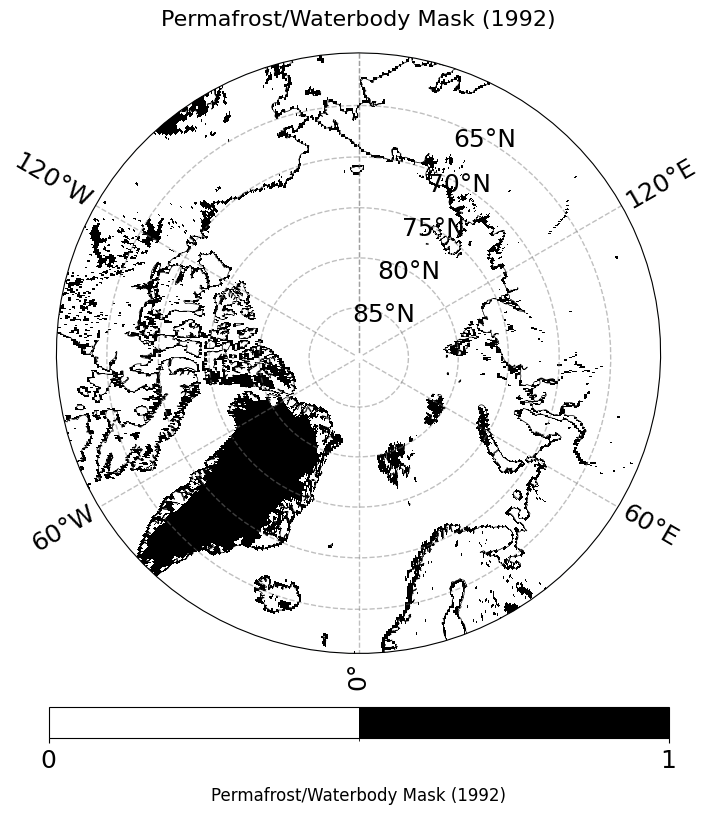

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Permafrost/Waterbody Mask (1992)'}>)

In [4]:
Permafrost_waterbody_mask_1992 = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask/Permafrost_waterbody_mask_25km_1992.nc'

with nc.Dataset(Permafrost_waterbody_mask_1992, 'r') as ds_mask:
    lat = ds_mask.variables["lat"][:]
    lon = ds_mask.variables["lon"][:]
    snowice_mask = np.ma.filled(ds_mask['snowice_mask'][:], np.nan)
    water_mask   = np.ma.filled(ds_mask['water_mask'][:], np.nan)
    combined_invalid = np.isnan(snowice_mask) | np.isnan(water_mask)

lon_2d, lat_2d = np.meshgrid(lon, lat)
bounds = [0, 0.5, 1]
plot_Northpole(lon_2d, lat_2d, combined_invalid, 'Permafrost/Waterbody Mask (1992)', 'binary', bounds=bounds, ticks=[0, 1]) # 0: Others, 1: Masked (Water/Ice)
